# CR Algorithm Test

## Useful Functions

In [1]:
import numpy as np

from pathlib import Path
import sys
sys.path.append(str(Path().resolve().parent))
print(sys.path[-1])
np.set_printoptions(precision=3)

/Users/magi-nerv/Space-Specifically/Stanford/AA273/horizon-op-nav


In [2]:
from numpy.linalg import norm, det
from numpy import sin, cos, tan, sqrt, pi, arctan, arctan2
import matplotlib.pyplot as plt
from datetime import datetime
from dataclasses import dataclass
import pytz
from enum import Enum

from utils import circle_points, camera_view, noise
from classes import Camera, Body, PlanetImage, Pose

PlanetaryData: Make sure to update position of bodies with position at specific time
e.g. `Earth["position"] = [1.0, 2.0, 3.0]  # km`


In [3]:
mu_unicode = "\u03bc"
deg_unicode = "\u00b0"

In [4]:
from filters import ChristianRobinson
from trajectory.Constants import RAD_TO_DEG, DEG_TO_RAD, ARCSEC_TO_RAD, RAD_TO_ARCSEC

## Camera

In [5]:
class CameraModel(Enum):
    SAGITTA = 0
    ST1 = 1

camera_model = CameraModel.SAGITTA

match camera_model:
    case CameraModel.SAGITTA:
        # Camera specs 
        # e.g. https://satsearch.co/products/arcsec-sagitta-star-tracker

        # Inputs
        fov = 25.2 * DEG_TO_RAD
        f = 2500e-3               # focal length
        n_pixels = np.array([2048, 2048])   # Assumed from previous star tracker

        cross_boresight_sigma = 2 * ARCSEC_TO_RAD
        boresight_sigma = 10 * ARCSEC_TO_RAD 
        # Calculated
        mu_angle = fov/n_pixels[0]       # pixel angle resolution [rad/px]
        mu = f * mu_angle             # pixel spacing [m/px]

    case CameraModel.ST1:
        # Camera specs 
        # e.g. https://spinworks.pt/products/star-tracker-st1/

        # Inputs
        fov_diag = 18.2 * DEG_TO_RAD
        f = 50e-3               # focal length
        n_pixels = np.array([2048, 2048])
        mu = 5.5e-6             # pixel spacing [m]
        cross_boresight_sigma = 2 * ARCSEC_TO_RAD / 3 # Gives in 3-sigma

        # Calculated
        mu_angle = mu / f       # pixel angle resolution [rad]
        fov = fov_diag / np.sqrt(2)

    
print(f"Pixel anglular resolution: {mu_angle*RAD_TO_ARCSEC:.2f} arcs/px")
print(f"Pixel resolution: {mu*1000000:.2f} {mu_unicode}m/px")
print(f"FOV: {fov*RAD_TO_DEG:.2f}{deg_unicode}")

Pixel anglular resolution: 44.30 arcs/px
Pixel resolution: 536.89 μm/px
FOV: 25.20°


## Initialization

In [6]:
# One-time calculation
camera = Camera(f, mu, n_pixels)
camera.calc_specs()
body = Body(a=3000, b=3000, c=3000)
print(camera)
print(body)

cr_alg = ChristianRobinson(camera.K_inv, body.a, body.b, body.c)

Camera base specs:
 - Pixel angular resolution: 44.30 arcs/px
 - Pixel resolution (μ): 536.89 μm/px
 - FOV: [25.2 25.2]°
 Calculated specs
 - Center (u_p, v_p) = [1024. 1024.] arcs/px
 - dx, dy = [4656.419 4656.419] (unitless?)
 - K_inv = 
[[ 2.148e-04  0.000e+00 -2.199e-01]
 [ 0.000e+00  2.148e-04 -2.199e-01]
 [ 0.000e+00  0.000e+00  1.000e+00]]

Worldview:
 - Ellipsoid semi-axes a,b,c = [3000, 3000, 3000] km



In [7]:
def run_step(rho_p_true, T_p_c, N = 100, offset = None , print_stats = False, plot_points = False):
    """
    rho: P->C
    
    r: C->P
    
    i.e. 
    r = -rho
    """
    rho_c_true = T_p_c @ rho_p_true # P->C in camera frame (i.e. as seen looking INTO the lens from the planet)
    r_c_true = -rho_c_true
    r_p_true = -rho_p_true

    if r_c_true[2] < 0:
        raise ValueError("Planet is behind the camera")

    # Calculate each time there is a new image
    pose = Pose(rho_p_true, T_p_c)
    img = PlanetImage(camera, body, 0.5)

    if offset is not None:
        offset = np.asarray(offset)
    img.gen_points(pose, N_RADIAL_POINTS=N, body_center_px=offset)
    # print(pose)
    # print(img)

    # Run algorithm (gives vector from camera TO planet in camera frame)
    print(img.u_in_frame)
    r_c_est = cr_alg.run(img.u_in_frame, pose.T_p_c)
    
    # Vector directions are flipped
    r_p_est = pose.T_p_c.T @ r_c_est


    # Print statistics
    if print_stats:
        with np.printoptions(precision=2, suppress=True):
            print(f"Calc Position:\n - (C->P in camera frame): {r_c_est} ({norm(r_c_est)})m")
            print(f" - (C->P in planet frame): {r_p_est} ({norm(r_p_est)})m")
            print(f"Actual position:\n - (C->P in camera frame): {r_c_true} ({norm(r_c_true)})m")
            print(f" - (C->P in planet frame): {r_p_true} ({norm(r_p_true)})m")
            print(f"Est - Actual:\n - (Camera frame): {r_c_est - r_c_true} ({norm(r_c_est - r_c_true)})m")
            print(f" - (Planet frame): {r_p_est - r_p_true} ({norm(r_p_est - r_p_true)})m")
            
            print(f"Distance error: {abs(norm(r_c_true) - norm(r_c_est))} m ({100*abs(norm(r_c_true) - norm(r_c_est))/norm(r_c_true):.10f}%)")
            
            print(f"Angular error: {np.degrees(np.arccos(np.dot(r_c_est, r_c_true) /(norm(r_c_est)*norm(r_c_true)))):.2f} degrees")

    if plot_points:
        print(img.res)
        # print(img.u_noise)
        if len(img.u_in_frame) > 0:
            plt.scatter(img.u_in_frame[:,0], img.u_in_frame[:,1])
        plt.xlim((0, camera.resolution[0]))
        plt.ylim((0, camera.resolution[1]))
        plt.show()

## Tests!

In [8]:
run_step(np.array([0, 0, -17000]), np.eye(3), print_stats=True)

[[1.860e+03 1.024e+03 1.000e+00]
 [1.857e+03 1.076e+03 1.000e+00]
 [1.852e+03 1.128e+03 1.000e+00]
 [1.844e+03 1.181e+03 1.000e+00]
 [1.833e+03 1.231e+03 1.000e+00]
 [1.818e+03 1.282e+03 1.000e+00]
 [1.801e+03 1.332e+03 1.000e+00]
 [1.780e+03 1.379e+03 1.000e+00]
 [1.755e+03 1.427e+03 1.000e+00]
 [1.729e+03 1.471e+03 1.000e+00]
 [1.699e+03 1.514e+03 1.000e+00]
 [1.667e+03 1.555e+03 1.000e+00]
 [1.632e+03 1.595e+03 1.000e+00]
 [1.595e+03 1.633e+03 1.000e+00]
 [1.556e+03 1.667e+03 1.000e+00]
 [1.515e+03 1.699e+03 1.000e+00]
 [1.472e+03 1.729e+03 1.000e+00]
 [1.427e+03 1.754e+03 1.000e+00]
 [1.380e+03 1.780e+03 1.000e+00]
 [1.332e+03 1.800e+03 1.000e+00]
 [1.282e+03 1.819e+03 1.000e+00]
 [1.232e+03 1.832e+03 1.000e+00]
 [1.181e+03 1.842e+03 1.000e+00]
 [1.129e+03 1.852e+03 1.000e+00]
 [1.076e+03 1.857e+03 1.000e+00]
 [1.023e+03 1.859e+03 1.000e+00]
 [9.715e+02 1.857e+03 1.000e+00]
 [9.188e+02 1.852e+03 1.000e+00]
 [8.676e+02 1.844e+03 1.000e+00]
 [8.159e+02 1.832e+03 1.000e+00]
 [7.662e+0

[[1.695e+03 1.025e+03 1.000e+00]
 [1.694e+03 1.066e+03 1.000e+00]
 [1.691e+03 1.109e+03 1.000e+00]
 [1.684e+03 1.150e+03 1.000e+00]
 [1.675e+03 1.192e+03 1.000e+00]
 [1.663e+03 1.232e+03 1.000e+00]
 [1.649e+03 1.272e+03 1.000e+00]
 [1.632e+03 1.310e+03 1.000e+00]
 [1.613e+03 1.347e+03 1.000e+00]
 [1.592e+03 1.384e+03 1.000e+00]
 [1.568e+03 1.419e+03 1.000e+00]
 [1.542e+03 1.453e+03 1.000e+00]
 [1.514e+03 1.484e+03 1.000e+00]
 [1.484e+03 1.515e+03 1.000e+00]
 [1.452e+03 1.541e+03 1.000e+00]
 [1.420e+03 1.568e+03 1.000e+00]
 [1.385e+03 1.592e+03 1.000e+00]
 [1.347e+03 1.613e+03 1.000e+00]
 [1.310e+03 1.632e+03 1.000e+00]
 [1.271e+03 1.649e+03 1.000e+00]
 [1.232e+03 1.663e+03 1.000e+00]
 [1.191e+03 1.675e+03 1.000e+00]
 [1.151e+03 1.684e+03 1.000e+00]
 [1.109e+03 1.692e+03 1.000e+00]
 [1.065e+03 1.696e+03 1.000e+00]
 [1.024e+03 1.696e+03 1.000e+00]
 [9.825e+02 1.695e+03 1.000e+00]
 [9.392e+02 1.691e+03 1.000e+00]
 [8.975e+02 1.684e+03 1.000e+00]
 [8.570e+02 1.675e+03 1.000e+00]
 [8.160e+0

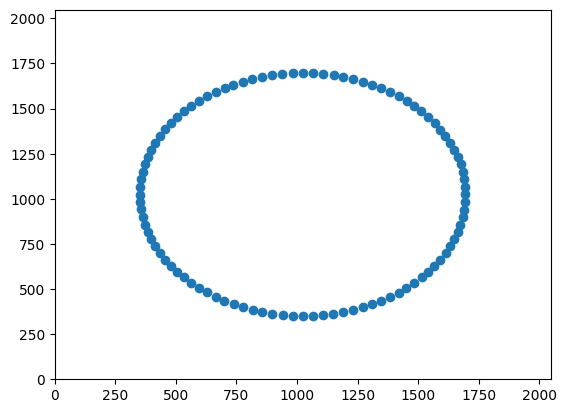

In [9]:
# 90 degree rotation because z axis of camera is along y axis
R = np.array([
    [0,1,0],
    [0,0,-1],
    [-1,0,0]
])

r = np.array([21000, 0, 0])
# r = np.array([21000, 1000, 0])
run_step(r, R, print_stats=True, plot_points=True)

[0.000e+00 5.912e-12 2.010e+04]
Position in frame of planet: [    0  2000 20000] (20099.751242241782)m
[[1.726e+03 1.023e+03 1.000e+00]
 [1.725e+03 1.068e+03 1.000e+00]
 [1.722e+03 1.113e+03 1.000e+00]
 [1.715e+03 1.156e+03 1.000e+00]
 [1.704e+03 1.198e+03 1.000e+00]
 [1.692e+03 1.241e+03 1.000e+00]
 [1.678e+03 1.281e+03 1.000e+00]
 [1.659e+03 1.323e+03 1.000e+00]
 [1.640e+03 1.363e+03 1.000e+00]
 [1.618e+03 1.400e+03 1.000e+00]
 [1.593e+03 1.437e+03 1.000e+00]
 [1.565e+03 1.472e+03 1.000e+00]
 [1.537e+03 1.505e+03 1.000e+00]
 [1.505e+03 1.537e+03 1.000e+00]
 [1.473e+03 1.566e+03 1.000e+00]
 [1.437e+03 1.594e+03 1.000e+00]
 [1.401e+03 1.618e+03 1.000e+00]
 [1.363e+03 1.640e+03 1.000e+00]
 [1.323e+03 1.660e+03 1.000e+00]
 [1.282e+03 1.677e+03 1.000e+00]
 [1.241e+03 1.691e+03 1.000e+00]
 [1.199e+03 1.705e+03 1.000e+00]
 [1.156e+03 1.715e+03 1.000e+00]
 [1.112e+03 1.721e+03 1.000e+00]
 [1.068e+03 1.726e+03 1.000e+00]
 [1.023e+03 1.727e+03 1.000e+00]
 [9.808e+02 1.725e+03 1.000e+00]
 [9.36

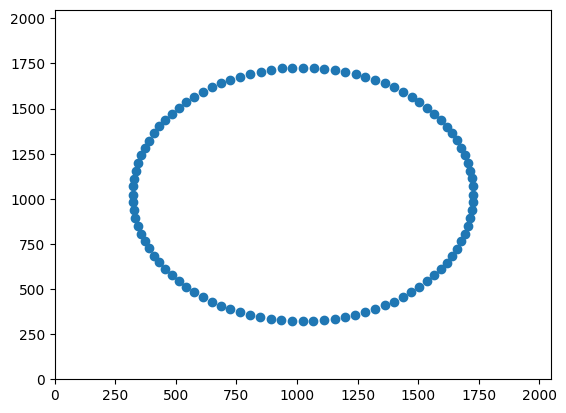

In [10]:
r = np.array([0, 2000, 20000])


# Rotated so the Z axis is looking at the planet (doesn't really matter where X and Y are)
angle = pi + arctan2(2000, 20000)

R = np.array([
    [1, 0, 0],
    [0, cos(angle), -sin(angle)],
    [0, sin(angle), cos(angle)],
])
look = R @ (-r)
print(look) # Make sure magnitude of Z is roughly the same as the norm of r

print(f"Position in frame of planet: {r} ({norm(r)})m")
run_step(r, R, 100, print_stats=True, plot_points=True)

Position in frame of planet: [ 5000  2000 15000] (15937.377450509228)m
[[3.765e+02 8.282e+02 1.000e+00]
 [3.756e+02 8.849e+02 1.000e+00]
 [3.697e+02 9.403e+02 1.000e+00]
 [3.611e+02 9.956e+02 1.000e+00]
 [3.488e+02 1.050e+03 1.000e+00]
 [3.320e+02 1.104e+03 1.000e+00]
 [3.129e+02 1.157e+03 1.000e+00]
 [2.919e+02 1.208e+03 1.000e+00]
 [2.660e+02 1.258e+03 1.000e+00]
 [2.370e+02 1.307e+03 1.000e+00]
 [2.067e+02 1.353e+03 1.000e+00]
 [1.719e+02 1.397e+03 1.000e+00]
 [1.348e+02 1.440e+03 1.000e+00]
 [9.530e+01 1.480e+03 1.000e+00]
 [5.327e+01 1.516e+03 1.000e+00]
 [8.524e+00 1.551e+03 1.000e+00]
 [8.948e+00 1.063e+02 1.000e+00]
 [5.340e+01 1.418e+02 1.000e+00]
 [9.540e+01 1.785e+02 1.000e+00]
 [1.346e+02 2.174e+02 1.000e+00]
 [1.720e+02 2.602e+02 1.000e+00]
 [2.072e+02 3.045e+02 1.000e+00]
 [2.377e+02 3.501e+02 1.000e+00]
 [2.658e+02 3.977e+02 1.000e+00]
 [2.923e+02 4.486e+02 1.000e+00]
 [3.134e+02 4.999e+02 1.000e+00]
 [3.336e+02 5.533e+02 1.000e+00]
 [3.478e+02 6.066e+02 1.000e+00]
 [3.6

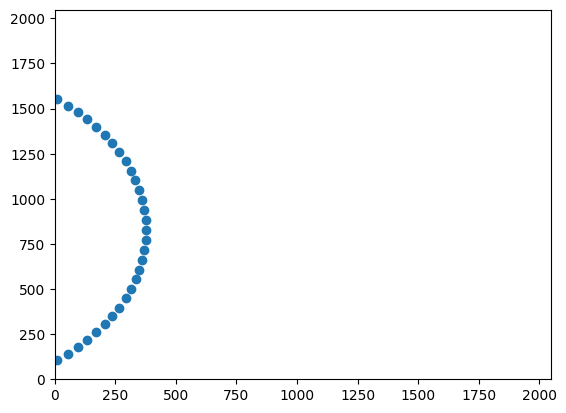

In [11]:
r = np.array([5000, 2000, 15000])

angle = -170 * DEG_TO_RAD
R = np.array([
    [1, 0, 0],
    [0, cos(angle), -sin(angle)],
    [0, sin(angle), cos(angle)],
])

print(f"Position in frame of planet: {r} ({norm(r)})m")
run_step(r, R, print_stats=True, plot_points=True)
# run_step(r, np.eye(3), print_stats=True, plot_points=True)

In [12]:
print(R @ [1,0,0])
print(R @ [0,1,0])
print(R @ [0,0,1])
print(R@[0, 7000, 0])

[1. 0. 0.]
[ 0.    -0.985 -0.174]
[ 0.     0.174 -0.985]
[    0.    -6893.654 -1215.537]
